# 12.13 整段平均後，還分得出哪個聲音先來嗎？


先有 440 Hz、再有 880 Hz，與把兩段順序交換不同；「哪段先來」的答案會變。先用已提取的時間框看這個問題：把框序列倒過來，框的集合不變，先後卻不同。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

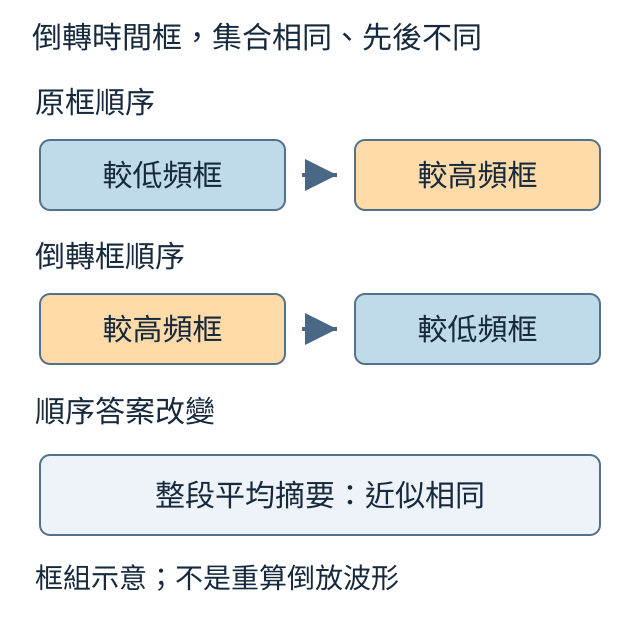

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-12-time-order.svg")))

In [3]:
from tiny_perceptron.natural_concepts import audio_order_report

report = audio_order_report()
print("時間框與頻帶", report["time_frames"], report["bands"])
print("先後序列相同", report["same_time_sequence"])
print("平均摘要近似相同", report["same_mean_with_roundoff_tolerance"])

時間框與頻帶 21 16
先後序列相同 False
平均摘要近似相同 True


工具將兩個合成單音串接後算 log-mel，得到 21 個時間框、16 個頻帶；再倒轉這份特徵的時間軸。序列相同印 False，平均摘要在容許浮點誤差下相同 True。這裡倒的是已取得的特徵框，不是重新合成另一段真人錄音，也不聲稱倒放波形的 STFT 逐格相同。

平均不管框在哪個位置，倒轉前後便可得到同一摘要；它可能保留兩種頻率的總量，卻失去「先低後高」的順序。若回答需要先後，入口與後續模型要保留時間位置，並接受相關任務的教學材料。

聽寫一句話更依賴有序聲音：同一批音節換位置，字串可能不同；回答需求則不一定要求逐字照抄。兩者都可能需要時間線索，但目標不同，不能以單音順序反例直接宣稱會聽寫，或以聽寫錯字直接判定需求答案必錯。

練習把問題改成「是否出現過較高的單音」，平均摘要是否可能足以幫忙？再改成「較高的先來嗎」，指出缺少的條件。接下來先介紹轉成文字的聊天路線，再設計保留聲音特徵的有限意圖路線。

<details>
<summary>回顧與查證</summary>

可回顧：[12.8沿時間保留特徵](https://birdhackor.github.io/tiny-perceptron-vlm/12.8.html)、[12.11先轉文字的取捨](https://birdhackor.github.io/tiny-perceptron-vlm/12.11.html)。

</details>
